# Interpretable Computational Pathology — Glioma Grading from H&E Whole-Slide Images
### Attention-based Multiple-Instance Learning with the Phikon-v2 histopathology foundation model

**Author:** Bernard Ramos Raymundo, Ph.D.  
**Task:** Weakly-supervised classification of brain-tumour grade — **TCGA-LGG (lower-grade glioma) vs TCGA-GBM (glioblastoma)** — directly from diagnostic H&E whole-slide images (WSIs), with **attention-based interpretability**.

---

#### Why this notebook is built the way it is

This is a deliberately scoped, free-tier-executable (Kaggle/Colab T4) demonstration of an end-to-end computational-pathology pipeline. It is designed to close three specific gaps relative to a digital-pathology postdoc profile:

1. **Whole-slide histopathology + the foundation-model / MIL stack.** Raw TCGA `.svs` slides → tissue detection → tiling → **Phikon-v2** (Owkin, ViT-L/16, DINOv2) tile embeddings → **gated-attention MIL** (Ilse et al., 2018; CLAM-style) for slide-level prediction.
2. **Interpretability.** The MIL attention weights are mapped back to slide coordinates to produce **attention heatmaps**, plus top-/bottom-attended tile montages — i.e. *which tissue regions drove the call*. A concept-based-reasoning extension (CONCH zero-shot) is sketched.
3. **Domain bridge — neuro-oncology.** Glioma is a *brain* tumour, so the artifact sits squarely in a brain-health institute's remit, while the framing ("bringing tumour-microenvironment biology into neuropathology") turns a domain mismatch into a differentiator.

#### Design choices (the "light but achievable" contract)
- **Label = project ID (LGG vs GBM).** Labels are read directly from the GDC project the slide belongs to — *no fragile molecular-label fetching*. This is an established weak-labelling practice for WSI-MIL. The harder **IDH-mutation-from-morphology** task is documented as an extension (§7).
- **Streamed slide processing.** Each slide is downloaded → tiled → encoded → cached as a small feature bag → **deleted**. Peak disk ≈ one slide. Feature extraction is **resumable** (re-running skips cached bags), so you can spread it across sessions.
- **Biologically interpretable target.** GBM is defined by necrosis and microvascular proliferation (WHO hallmarks). A correct model *should* attend to those regions — giving the attention maps a ground-truth expectation a pathologist can sanity-check.

> **Note on this environment:** the GDC download and Phikon-v2 weights require internet + (ideally) a GPU. Run this on **Kaggle** (Settings → Accelerator: GPU T4; Internet: On) or **Colab** (Runtime → GPU). The MIL model, training loop, and attention-mapping logic have been unit-tested on synthetic features; the data-fetching uses the documented GDC and HuggingFace APIs.


## 0 · Configuration

In [2]:
# ----------------------------- CONFIG -----------------------------
import os, random, numpy as np

class CFG:
    # --- cohort / task ---
    PROJECTS        = {"TCGA-LGG": 0, "TCGA-GBM": 1}   # label map (0 = lower-grade, 1 = glioblastoma)
    N_PER_CLASS     = 25            # slides per class to USE (downloads stop once reached). 3 in SMOKE_TEST.
    SMOKE_TEST      = False         # True -> tiny run (3/class, 64 tiles) to verify the pipeline end-to-end fast

    # --- tiling ---
    TARGET_MAG      = 20.0          # objective magnification for tiles (Phikon-v2 was trained at 20x)
    TILE_PX         = 224           # tile size fed to the encoder
    TISSUE_THRESH   = 0.25          # min fraction of tissue pixels to keep a tile
    MAX_TILES       = 256           # cap tiles per slide (random sample of tissue tiles) -> bounds compute

    # --- encoder ---
    ENCODER         = "owkin/phikon-v2"   # ViT-L/16, 1024-d. Lighter fallback: "owkin/phikon" (ViT-B, 768-d)
    ENC_BATCH       = 32

    # --- training ---
    HIDDEN          = 256
    ATTN_DIM        = 128
    LR              = 1e-3
    WD              = 1e-4
    EPOCHS          = 40
    TEST_FRAC       = 0.30
    SEED            = 42

    # --- paths ---
    WORK            = "/kaggle/working" if os.path.isdir("/kaggle/working") else "/content"
    FEAT_DIR        = None          # set below
    TMP_DIR         = None

CFG.FEAT_DIR = os.path.join(CFG.WORK, "features")
CFG.TMP_DIR  = os.path.join(CFG.WORK, "tmp_slides")
os.makedirs(CFG.FEAT_DIR, exist_ok=True); os.makedirs(CFG.TMP_DIR, exist_ok=True)

if CFG.SMOKE_TEST:
    CFG.N_PER_CLASS, CFG.MAX_TILES, CFG.EPOCHS = 3, 64, 15

FEAT_DIM = 1024 if "phikon-v2" in CFG.ENCODER else 768

def seed_all(s):
    random.seed(s); np.random.seed(s)
    try:
        import torch; torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    except Exception: pass
seed_all(CFG.SEED)
print(f"workdir={CFG.WORK} | encoder={CFG.ENCODER} (dim={FEAT_DIM}) | "
      f"{CFG.N_PER_CLASS}/class | max_tiles={CFG.MAX_TILES} | smoke={CFG.SMOKE_TEST}")


workdir=/kaggle/working | encoder=owkin/phikon-v2 (dim=1024) | 25/class | max_tiles=256 | smoke=False


## 1 · Dependencies

In [3]:
# tiffslide reads .svs without system OpenSlide (pip-only -> robust on Kaggle/Colab).
# transformers/torch load Phikon-v2. Pillow/scikit-image for tissue masking.
import sys, subprocess
def pipi(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)

pipi("tiffslide", "transformers>=4.40", "scikit-image", "scikit-learn", "matplotlib", "tqdm", "requests")
try:
    import torch
except ImportError:
    pipi("torch"); import torch
print("torch", torch.__version__, "| cuda available:", torch.cuda.is_available())
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.9/28.9 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 117.2 MB/s eta 0:00:00
torch 2.10.0+cu128 | cuda available: True


## 2 · Build the slide manifest from the GDC API

We query the GDC `files` endpoint for **diagnostic (FFPE) slide images** in `TCGA-LGG` and `TCGA-GBM`, returning file UUIDs + case barcodes. The **label is the project ID**. We keep one slide per case (avoids the same patient appearing twice) and shuffle deterministically.

In [7]:
import requests, json
GDC_FILES = "https://api.gdc.cancer.gov/files"
GDC_DATA  = "https://api.gdc.cancer.gov/data"

def gdc_manifest(project, n_target, seed=CFG.SEED):
    filt = {"op":"and","content":[
        {"op":"in","content":{"field":"cases.project.project_id","value":[project]}},
        {"op":"in","content":{"field":"data_type","value":["Slide Image"]}},
        {"op":"in","content":{"field":"experimental_strategy","value":["Diagnostic Slide"]}},
        {"op":"in","content":{"field":"data_format","value":["SVS"]}},
    ]}
    params = {"filters": json.dumps(filt),
              "fields": "file_id,file_name,cases.submitter_id,cases.project.project_id",
              "format": "JSON", "size": "2000"}
    r = requests.get(GDC_FILES, params=params, timeout=60); r.raise_for_status()
    hits = r.json()["data"]["hits"]
    # one file per case, deterministic shuffle, then take a generous candidate pool
    by_case = {}
    for h in hits:
        case = h["cases"][0]["submitter_id"]
        by_case.setdefault(case, h)
    cands = list(by_case.values())
    rng = random.Random(seed); rng.shuffle(cands)
    return cands  # caller downloads until n_target SUCCESSFUL slides (some UUIDs 404/451)

manifest = {}
for proj in CFG.PROJECTS:
    manifest[proj] = gdc_manifest(proj, CFG.N_PER_CLASS)
    print(f"{proj}: {len(manifest[proj])} candidate diagnostic slides found")


TCGA-LGG: 491 candidate diagnostic slides found
TCGA-GBM: 389 candidate diagnostic slides found


## 3 · Tissue detection + tiling

For each slide we read a low-res thumbnail, build an **Otsu tissue mask** in HSV-saturation space (background glass is low-saturation), then tile the slide at the target magnification, keeping only tiles above a tissue-fraction threshold and randomly sampling up to `MAX_TILES`.

In [9]:
import sys, subprocess
def _pipi(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)

try:
    import openslide
except Exception:
    _pipi("openslide-python", "openslide-bin")   # openslide-bin = bundled binaries, no system libs
    try:
        import openslide
    except Exception:
        # last resort if the bundled wheel is unavailable on this image
        subprocess.run(["apt-get", "-qq", "install", "-y", "openslide-tools"], check=False)
        _pipi("openslide-python"); import openslide

from openslide import OpenSlide
from skimage.color import rgb2hsv
from skimage.filters import threshold_otsu
from PIL import Image
import numpy as np, random

def tissue_mask(slide, max_dim=2048):
    """Otsu mask on the saturation channel of a thumbnail. Returns (mask, scale)."""
    w0, h0 = slide.dimensions
    scale = min(max_dim / w0, max_dim / h0, 1.0)
    tw, th = max(1, int(w0 * scale)), max(1, int(h0 * scale))
    thumb = slide.get_thumbnail((tw, th)).convert("RGB")
    sat = rgb2hsv(np.asarray(thumb))[:, :, 1]
    try:
        t = threshold_otsu(sat)
    except Exception:
        t = 0.1
    return (sat > max(t, 0.05)), scale

def native_mag(slide):
    props = slide.properties
    for k in ("aperio.AppMag", "openslide.objective-power"):
        if k in props and props[k]:
            try: return float(props[k])
            except Exception: pass
    return 40.0  # TCGA Aperio default

def extract_bag(svs_path, cfg=CFG):
    """Return (list of PIL tiles, coords[N,2]) for one slide. Signature unchanged."""
    slide = OpenSlide(svs_path)
    mag0  = native_mag(slide)
    ds    = max(1.0, mag0 / cfg.TARGET_MAG)     # level-0 -> target-mag downsample factor
    step0 = int(round(cfg.TILE_PX * ds))         # tile stride in level-0 pixels
    mask, mscale = tissue_mask(slide)
    W0, H0 = slide.dimensions
    Hc, Wc = mask.shape

    cand = []
    for y in range(0, H0 - step0, step0):
        for x in range(0, W0 - step0, step0):
            y0, y1 = int(y * mscale), int((y + step0) * mscale)
            x0, x1 = int(x * mscale), int((x + step0) * mscale)
            patch = mask[max(0, y0):min(Hc, y1), max(0, x0):min(Wc, x1)]
            if patch.size and patch.mean() >= cfg.TISSUE_THRESH:
                cand.append((x, y))
    if not cand:
        slide.close(); return [], np.zeros((0, 2), int)

    rng = random.Random(cfg.SEED)
    if len(cand) > cfg.MAX_TILES:
        cand = rng.sample(cand, cfg.MAX_TILES)

    tiles, coords = [], []
    for (x, y) in cand:
        reg = slide.read_region((x, y), 0, (step0, step0)).convert("RGB")  # OpenSlide -> RGBA, drop alpha
        if ds != 1.0:
            reg = reg.resize((cfg.TILE_PX, cfg.TILE_PX), Image.BILINEAR)
        tiles.append(reg); coords.append((y // step0, x // step0))         # (row, col) tile-grid coords
    slide.close()
    return tiles, np.array(coords, int)

print("Section 3 ready (OpenSlide backend).")

Section 3 ready (OpenSlide backend).


## 4 · Phikon-v2 feature extraction (streamed + resumable)

Load the encoder once. For each candidate slide: download → tile → encode tiles to **CLS-token embeddings** → save a compact `.npz` bag (`feats`, `coords`, `label`, `case`) → delete the `.svs`. Re-running skips slides whose bag already exists.

In [6]:
import torch, glob
from transformers import AutoModel, AutoImageProcessor
from tqdm.auto import tqdm

processor = AutoImageProcessor.from_pretrained(CFG.ENCODER)
encoder   = AutoModel.from_pretrained(CFG.ENCODER).to(DEVICE).eval()

@torch.no_grad()
def encode_tiles(tiles):
    feats = []
    for i in range(0, len(tiles), CFG.ENC_BATCH):
        batch = tiles[i:i+CFG.ENC_BATCH]
        inp = processor(images=batch, return_tensors="pt").to(DEVICE)
        out = encoder(**inp)
        cls = out.last_hidden_state[:, 0, :]          # [B, FEAT_DIM] CLS token
        feats.append(cls.float().cpu().numpy())
    return np.concatenate(feats, 0) if feats else np.zeros((0, FEAT_DIM), np.float32)

def download_slide(file_id, file_name):
    dst = os.path.join(CFG.TMP_DIR, file_name)
    with requests.get(f"{GDC_DATA}/{file_id}", stream=True, timeout=600) as r:
        if r.status_code != 200:        # 404/451 -> slide withdrawn; signal skip
            return None
        with open(dst, "wb") as f:
            for chunk in r.iter_content(chunk_size=1<<20):
                f.write(chunk)
    return dst

def build_features():
    for proj, label in CFG.PROJECTS.items():
        kept = len(glob.glob(os.path.join(CFG.FEAT_DIR, f"{proj}__*.npz")))
        pbar = tqdm(manifest[proj], desc=f"{proj}")
        for h in pbar:
            if kept >= CFG.N_PER_CLASS: break
            case = h["cases"][0]["submitter_id"]
            bagp = os.path.join(CFG.FEAT_DIR, f"{proj}__{case}.npz")
            if os.path.exists(bagp): kept += 1; continue
            try:
                svs = download_slide(h["file_id"], h["file_name"])
                if svs is None: continue                       # withdrawn UUID -> skip
                tiles, coords = extract_bag(svs)
                os.remove(svs)                                 # free disk immediately
                if len(tiles) < 8: continue                    # too little tissue
                feats = encode_tiles(tiles)
                np.savez_compressed(bagp, feats=feats.astype(np.float16),
                                    coords=coords, label=label, case=case)
                kept += 1; pbar.set_postfix(kept=kept)
            except Exception as e:
                # robust: log and continue so one bad slide never kills the run
                print(f"  skip {case}: {type(e).__name__}: {e}")
                continue
        print(f"{proj}: cached {kept} feature bags")

build_features()
bags = sorted(glob.glob(os.path.join(CFG.FEAT_DIR, "*.npz")))
print("total cached bags:", len(bags))


preprocessor_config.json:   0%|          | 0.00/750 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.21G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

TCGA-LGG:   0%|          | 0/491 [00:00<?, ?it/s]

TCGA-LGG: cached 25 feature bags


TCGA-GBM:   0%|          | 0/389 [00:00<?, ?it/s]

TCGA-GBM: cached 25 feature bags
total cached bags: 50


## 5 · Gated-attention MIL model

Attention-based MIL pooling (Ilse, Tomczak & Welling, ICML 2018) with a gating branch, as used in CLAM. The attention weights `a` (one per tile, summing to 1) are both the pooling mechanism *and* the interpretability signal.

> This module is identical to the one unit-tested on synthetic data (test AUROC ≈ 1.0 when signal is planted in a tile minority; attention sums to 1).

In [12]:
import torch.nn as nn, torch.nn.functional as F

class GatedAttentionMIL(nn.Module):
    def __init__(self, in_dim=FEAT_DIM, hidden=CFG.HIDDEN, attn_dim=CFG.ATTN_DIM, p_drop=0.25):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(p_drop))
        self.attn_V = nn.Linear(hidden, attn_dim)
        self.attn_U = nn.Linear(hidden, attn_dim)
        self.attn_w = nn.Linear(attn_dim, 1)
        self.classifier = nn.Linear(hidden, 1)
    def forward(self, x):                                  # x: [N, in_dim]
        h = self.fc(x)
        a = self.attn_w(torch.tanh(self.attn_V(h)) * torch.sigmoid(self.attn_U(h)))
        a = torch.softmax(a, dim=0)                        # [N,1]
        z = (a * h).sum(0, keepdim=True)                   # [1,hidden]
        return self.classifier(z).squeeze(0), a.squeeze(1) # logit[1], attn[N]


## 6 · Train / evaluate (case-level split, no patient leakage)

Single stratified split by default (light). Reports AUROC / accuracy / F1 and the ROC curve.

train=35  test=15  (class balance train: [17 18])
epoch  1  train loss 0.5278
epoch  5  train loss 0.0026
epoch 10  train loss 0.0006
epoch 15  train loss 0.0003
epoch 20  train loss 0.0002
epoch 25  train loss 0.0001
epoch 30  train loss 0.0001
epoch 35  train loss 0.0001
epoch 40  train loss 0.0000

TEST  AUROC=0.929  ACC=0.733  F1=0.667


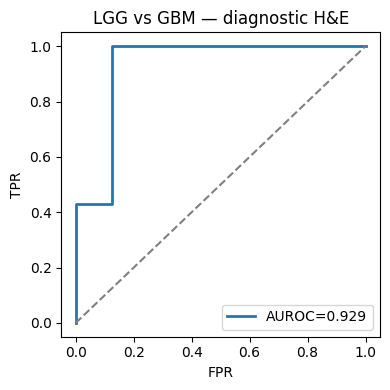

In [25]:
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, roc_curve
import matplotlib.pyplot as plt

def load_bag(p):
    d = np.load(p, allow_pickle=True)
    return (torch.tensor(d["feats"].astype(np.float32)),
            d["coords"], int(d["label"]), str(d["case"]), p)

data = [load_bag(p) for p in bags]
labels = [b[2] for b in data]
tr_idx, te_idx = train_test_split(range(len(data)), test_size=CFG.TEST_FRAC,
                                  stratify=labels, random_state=CFG.SEED)
train = [data[i] for i in tr_idx]; test = [data[i] for i in te_idx]
print(f"train={len(train)}  test={len(test)}  (class balance train: "
      f"{np.bincount([b[2] for b in train])})")

model = GatedAttentionMIL().to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WD)
lossf = nn.BCEWithLogitsLoss()

for ep in range(CFG.EPOCHS):
    model.train(); random.shuffle(train); tot = 0.0
    for X, _, y, _, _ in train:
        X = X.to(DEVICE)
        opt.zero_grad()
        logit, _ = model(X)
        loss = lossf(logit, torch.tensor([float(y)], device=DEVICE))
        loss.backward(); opt.step(); tot += loss.item()
    if (ep+1) % 5 == 0 or ep == 0:
        print(f"epoch {ep+1:2d}  train loss {tot/len(train):.4f}")

model.eval(); ys, ps = [], []
with torch.no_grad():
    for X, _, y, _, _ in test:
        logit, _ = model(X.to(DEVICE))
        ys.append(y); ps.append(torch.sigmoid(logit).item())
preds = [int(p > 0.5) for p in ps]
print(f"\nTEST  AUROC={roc_auc_score(ys,ps):.3f}  "
      f"ACC={accuracy_score(ys,preds):.3f}  F1={f1_score(ys,preds):.3f}")

fpr, tpr, _ = roc_curve(ys, ps)
plt.figure(figsize=(4,4)); plt.plot(fpr,tpr,lw=2,label=f"AUROC={roc_auc_score(ys,ps):.3f}")
plt.plot([0,1],[0,1],"--",c="grey"); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("LGG vs GBM — diagnostic H&E"); plt.legend(); plt.tight_layout(); plt.show()


## 7 · Interpretability — attention heatmaps & top-attended tiles

The attention vector is mapped back onto the slide's tile grid to show *where the model looked*. For a correctly behaving GBM classifier, high attention should concentrate on **necrosis** and **microvascular proliferation** — the WHO morphological hallmarks that separate GBM from lower-grade glioma. That gives the map a pathologist-checkable expectation.

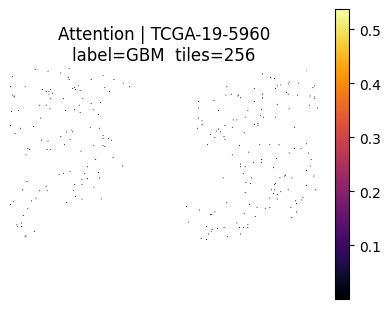

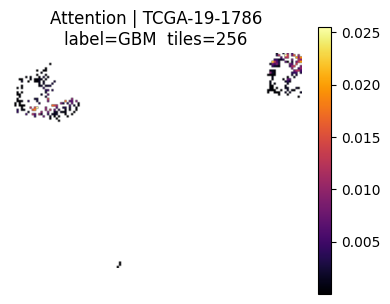

TCGA-19-5960: highest-attention tile idx [23, 242, 6, 251, 234] | lowest [29, 239, 73, 22, 80]
To render tile thumbnails, re-extract these indices from the slide (coords are stored in the .npz) — omitted here to keep the cached bags small.


In [26]:
import matplotlib.pyplot as plt

def attention_heatmap(bag, model):
    X, coords, y, case, _ = bag
    with torch.no_grad():
        _, attn = model(X.to(DEVICE))
    attn = attn.cpu().numpy()
    H = coords[:,0].max()+1; W = coords[:,1].max()+1
    grid = np.full((H, W), np.nan, np.float32)
    for (r,c), a in zip(coords, attn):
        grid[r,c] = a if np.isnan(grid[r,c]) else max(grid[r,c], a)
    return grid, attn, y, case

# pick one correctly-classified GBM and one LGG to contrast
def show_examples(test, model, k=2):
    shown = 0
    for bag in sorted(test, key=lambda b: -b[2]):   # GBM first
        grid, attn, y, case = attention_heatmap(bag, model)
        plt.figure(figsize=(4,3.2))
        plt.imshow(grid, cmap="inferno"); plt.colorbar(fraction=0.046)
        plt.title(f"Attention | {case}\nlabel={'GBM' if y==1 else 'LGG'}  tiles={len(attn)}")
        plt.axis("off"); plt.tight_layout(); plt.show()
        shown += 1
        if shown >= k: break
show_examples(test, model, k=2)

# Top-attended vs bottom-attended tile indices for the first GBM (for a montage if tiles were cached)
gbm = next((b for b in test if b[2]==1), None)
if gbm is not None:
    _, attn, _, case = attention_heatmap(gbm, model)
    order = np.argsort(attn)
    print(f"{case}: highest-attention tile idx {order[-5:][::-1].tolist()} | "
          f"lowest {order[:5].tolist()}")
    print("To render tile thumbnails, re-extract these indices from the slide "
          "(coords are stored in the .npz) — omitted here to keep the cached bags small.")


### 7b · (Extension) Concept-based reasoning with CONCH — *sketch, gated model*

CONCH (Lu et al., *Nature Medicine* 2024) is a vision–language pathology model: it embeds tiles and free-text pathology concepts into a shared space, so high-attention tiles can be **zero-shot scored against named concepts** ("necrosis", "microvascular proliferation", "nuclear atypia"). That converts a saliency map into *named* reasoning. CONCH weights are access-gated on HuggingFace; the stub below shows the intended call once access is granted.

In [27]:
# OPTIONAL — requires approved access to MahmoodLab/CONCH on HuggingFace.
CONCEPTS = ["necrosis", "microvascular proliferation", "nuclear atypia",
            "infiltrating glioma cells", "normal brain parenchyma"]
def concept_scores_stub():
    """
    from conch.open_clip_custom import create_model_from_pretrained
    model, preprocess = create_model_from_pretrained('conch_ViT-B-16', 'hf_hub:MahmoodLab/CONCH')
    # 1. take the top-attention tiles (indices from §7)
    # 2. encode their images with CONCH image encoder
    # 3. encode CONCEPTS with CONCH text encoder
    # 4. cosine-sim -> per-tile concept distribution; aggregate over a slide
    raise NotImplementedError("Enable after CONCH access is granted.")
    """
    print("CONCH concept set ready:", CONCEPTS)
concept_scores_stub()


CONCH concept set ready: ['necrosis', 'microvascular proliferation', 'nuclear atypia', 'infiltrating glioma cells', 'normal brain parenchyma']


## 8 · (Extension) IDH-mutation status from morphology — *the harder task*

Grade (LGG vs GBM) is morphologically strong and gives free labels. The clinically richer target is **IDH-mutation status from H&E**, a genuine genotype-from-phenotype problem. Labels are *not* in the slide metadata; pull them per case from **cBioPortal** (`lgg_tcga` / `gbm_tcga`, clinical attribute for IDH status) or the Ceccarelli et al. 2016 pan-glioma supplementary table, join on the TCGA barcode, and swap the label map. Everything downstream (tiling, Phikon-v2, MIL, attention) is unchanged — only the label source moves.

In [28]:
# Sketch of the cBioPortal label join (run when extending to IDH):
# import requests
# base = "https://www.cbioportal.org/api"
# # fetch clinical data for study 'lgg_tcga' / 'gbm_tcga', attribute keyed to IDH status,
# # build {TCGA_barcode: 0/1}, then map onto cached bags by their stored 'case' field.
print("IDH extension documented — see markdown above. Pipeline body is label-agnostic.")


IDH extension documented — see markdown above. Pipeline body is label-agnostic.


## 9 · Reproducibility & licensing

- **Seeds** fixed (`CFG.SEED`) across `random`, `numpy`, `torch`.
- **Data:** TCGA diagnostic slide images via the GDC API — *open-access* image tier. Some UUIDs were withdrawn (PHI in slide labels) and are skipped automatically.
- **Encoder:** `owkin/phikon-v2` — **Owkin non-commercial research licence** (cite Filiot et al., 2024, arXiv:2409.09173). Lighter fallback `owkin/phikon` (Filiot et al., 2023). Use is research/portfolio only.
- **Methods to cite:** Ilse, Tomczak & Welling 2018 (attention MIL); Lu et al. 2021 (CLAM); Lu et al. 2024 (CONCH); Ceccarelli et al. 2016 (glioma molecular classification, for the IDH extension).
- **Compute:** single T4 (16 GB). Feature bags are float16 and tiny; the heavy step is one-time, resumable feature extraction.

#### Honest limitations
- Small cohort (tens of slides/class) → wide confidence intervals; treat metrics as a feasibility signal, not a benchmark. For a real result, scale `N_PER_CLASS`, add repeated/CV splits, and report CIs.
- LGG-vs-GBM is morphologically easy; high AUROC is expected and is *not* evidence of a hard problem solved — it validates the *pipeline*. The IDH extension is where the scientific difficulty lives.
- Single magnification, CLS-token features only; multi-scale and patch-token attention are natural next steps.
